# 04. ML 엔진 학습 — 피처 조합과 불균형 처리 비교

Phase 3 `MlEngine`이 호출할 모델을 만든다. 실험 결과로 정한 설정은 `scripts/train.py`에 고정하고, 모델 파일은 그 스크립트가 만든다.

**설계 결정** (`docs/decisions.md` D-015)
- 모델: scikit-learn `HistGradientBoostingClassifier`
- 예측 대상: 다중분류 1개 모델 (NORMAL / HDF / PWF / OSF / TWF). 룰 엔진과 같은 형태(이상 여부, 심각도, 유형)로 답한다
- 비교 실험: 피처 2종(원본 / 원본 + 파생변수) × 불균형 처리 3종(없음 / class_weight / SMOTE)

**공정한 비교를 위한 규칙** (원칙 3)
- 모델 선택, 불균형 처리, 임계값은 **train 행의 5-fold 교차검증(OOF)** 으로만 정한다
- test 행(D-005)은 마지막 6절에서 **한 번만** 평가한다. 지표는 룰 엔진과 같다 (`machineFailure` 기준 정밀도·재현율·F1)

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score, log_loss,
                             precision_recall_curve, precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold

sys.path.insert(0, str(Path.cwd().parent))  # ml-server/
from app.features import CLASSES, FEATURE_SETS, NORMAL, load_dataset, to_matrix
from scripts import train as T

# 색: 범주 슬롯 1~3 (blue, orange, aqua) 고정 순서
COLORS = {"none": "#2a78d6", "class_weight": "#eb6834", "smote": "#1baf7a"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5", "axes.axisbelow": True})

df = load_dataset()
train = df[df["split"] == "train"].reset_index(drop=True)
test = df[df["split"] == "test"].reset_index(drop=True)
y_train = train["machineFailure"].to_numpy()
y_test = test["machineFailure"].to_numpy()
len(train), len(test)

(8000, 2000)

## 1. 학습 라벨

- `machineFailure = 0` → NORMAL (RNF 단독 18건 포함, D-003)
- 고장이면 유형 라벨 중 하나를 대표로 고른다. 여러 유형이 겹치면 룰 엔진과 같은 우선순위 HDF > PWF > OSF > TWF (D-011)
- 유형 라벨이 없는 고장은 원인을 알 수 없어 **학습에서만 제외**한다. 평가에서는 그대로 고장으로 남는다 → 어떤 엔진도 잡기 어려운 재현율 손실

In [2]:
pd.crosstab(df["label"].fillna("(유형 없음, 학습 제외)"), df["split"], margins=True)

split,test,train,All
label,,,
"(유형 없음, 학습 제외)",2,7,9
HDF,29,86,115
NORMAL,1932,7729,9661
OSF,16,64,80
PWF,12,80,92
TWF,9,34,43
All,2000,8000,10000


## 2. 평가 방식

- **OOF 확률**: train을 `machineFailure`로 층화한 5-fold로 나누고, 각 fold를 나머지 4개로 학습한 모델로 예측한다. SMOTE는 fold 안의 학습 부분에만 적용한다 (합성 샘플이 검증 fold로 새지 않도록)
- **고장 확률** = 1 − P(NORMAL). 이 값으로 이진 판정을 평가한다
- **주 지표: AP (Average Precision, PR 곡선 아래 면적)**. 임계값과 무관하게 모델을 비교할 수 있고, 양성이 3.4%뿐이라 ROC-AUC보다 차이가 잘 드러난다
- 보조 지표: F1이 최대가 되는 임계값에서의 F1 / 정밀도 / 재현율
- fold별 AP도 함께 본다 — 평균이 같아도 fold마다 흔들리면 믿기 어렵다

함수(`oof_proba`, `best_f1_threshold` 등)는 `scripts/train.py`에 있다. 노트북과 학습 스크립트가 같은 코드를 쓴다.

In [3]:
def per_fold_ap(features, imbalance, make=T.make_model):
    """fold별 AP와 학습 데이터 log loss (수렴 여부 확인용)."""
    x = to_matrix(train, features)
    labels = train["label"].to_numpy()
    rows = []
    for fold, (fit_idx, val_idx) in enumerate(StratifiedKFold(T.N_FOLDS, shuffle=True, random_state=T.SEED)
                                              .split(x, y_train)):
        fit_idx = fit_idx[pd.notna(labels[fit_idx])]
        x_fit, y_fit = x[fit_idx], labels[fit_idx]
        if imbalance == "smote":
            x_fit, y_fit = T.SMOTE(random_state=T.SEED).fit_resample(x_fit, y_fit)
        model = make(imbalance).fit(x_fit, y_fit)
        p_fail = T.failure_proba(T.proba_in_class_order(model, x[val_idx]))
        rows.append({"fold": fold, "AP": average_precision_score(y_train[val_idx], p_fail),
                     "train_logloss": log_loss(y_fit, model.predict_proba(x_fit), labels=model.classes_)})
    return pd.DataFrame(rows)

## 3. 기본 하이퍼파라미터의 학습 발산

처음에는 `HistGradientBoostingClassifier` 기본값(`learning_rate=0.1`, 규제 없음)으로 비교했는데, **원본 + 파생변수 / 불균형 처리 없음** 조합의 AP가 무작위 수준까지 떨어졌다.
파생변수를 넣었더니 성능이 무너지는 것은 이상해서 fold별로 확인했다.

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier

default_model = lambda imbalance: HistGradientBoostingClassifier(random_state=T.SEED)
pd.concat({
    "기본값 (lr 0.1, 규제 없음)": per_fold_ap(FEATURE_SETS["raw+derived"], "none", make=default_model),
    f"수정 (lr {T.LEARNING_RATE}, L2 {T.L2_REGULARIZATION})": per_fold_ap(FEATURE_SETS["raw+derived"], "none"),
}).round(4)

fold      AP  train_logloss
기본값 (lr 0.1, 규제 없음) 0     0  0.0329         4.7888
                    1     1  0.1058         2.8503
                    2     2  0.0438         1.3462
                    3     3  0.0563         1.5790
                    4     4  0.1159         1.8268
수정 (lr 0.1, L2 1.0) 0     0  0.9056         0.0009
                    1     1  0.8932         0.0009
                    2     2  0.9369         0.0009
                    3     3  0.8895         0.0008
                    4     4  0.8489         0.0009

**해석**
- 기본값에서는 fold마다 AP가 크게 흔들리고, **학습 데이터의 log loss가 1 이상**이다. 학습 데이터조차 맞히지 못한다는 것은 과적합이 아니라 최적화가 발산했다는 뜻이다
- 파생변수가 들어가면 클래스가 거의 완벽히 갈라져서 부스팅이 잎 값을 크게 키우고, 다중분류 softmax에서 단계가 넘친 것으로 보인다
- L2 규제(`l2_regularization=1.0`)를 주면 모든 fold에서 수렴한다 (학습 log loss ≈ 0)
- 이대로 비교했다면 "불균형 처리를 안 하면 망가진다"는 **틀린 결론**을 냈을 것이다. 이후 모든 조합을 같은 수정 하이퍼파라미터로 비교한다
- 하이퍼파라미터는 train 교차검증만 보고 정했다 (test 미사용)

## 4. 피처 조합 × 불균형 처리 비교 (train 5-fold OOF)

In [5]:
IMBALANCES = ["none", "class_weight", "smote"]
oof, rows = {}, []
for feature_set, features in FEATURE_SETS.items():
    for imbalance in IMBALANCES:
        folds = per_fold_ap(features, imbalance)
        oof[(feature_set, imbalance)] = p_fail = T.failure_proba(T.oof_proba(train, features, imbalance))
        best = T.best_f1_threshold(y_train, p_fail)
        rows.append({"피처": feature_set, "불균형 처리": imbalance,
                     "AP (OOF)": best["average_precision"],
                     "AP fold 평균": folds["AP"].mean(), "AP fold 표준편차": folds["AP"].std(),
                     "최대 학습 logloss": folds["train_logloss"].max(),
                     "best F1": best["f1"], "정밀도": best["precision"], "재현율": best["recall"],
                     "임계값": best["threshold"]})
comparison = pd.DataFrame(rows).set_index(["피처", "불균형 처리"])
comparison.round(3)

AP (OOF)  AP fold 평균  AP fold 표준편차  최대 학습 logloss  \
피처          불균형 처리                                                            
raw         none             0.826       0.831         0.032          0.002   
            class_weight     0.819       0.826         0.024          0.007   
            smote            0.815       0.818         0.020          0.002   
raw+derived none             0.896       0.895         0.032          0.001   
            class_weight     0.909       0.910         0.032          0.003   
            smote            0.908       0.909         0.032          0.002   

                          best F1    정밀도    재현율    임계값  
피처          불균형 처리                                      
raw         none            0.774  0.805  0.745  0.290  
            class_weight    0.767  0.808  0.731  0.818  
            smote           0.761  0.860  0.683  0.981  
raw+derived none            0.865  0.936  0.804  0.447  
            class_weight    0.903  0.996  0.827  0.954  
            smote           0.878  0.977  0.797  0.996

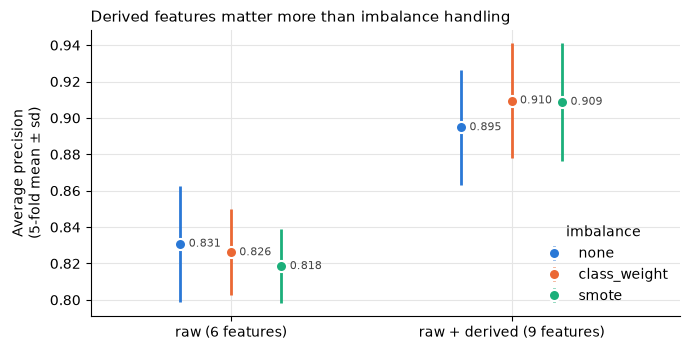

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.6))
offset = 0.18
feature_sets = list(FEATURE_SETS)
for i, imbalance in enumerate(IMBALANCES):
    means = [comparison.loc[(fs, imbalance), "AP fold 평균"] for fs in feature_sets]
    stds = [comparison.loc[(fs, imbalance), "AP fold 표준편차"] for fs in feature_sets]
    xs = np.arange(len(feature_sets)) + (i - 1) * offset
    ax.errorbar(xs, means, yerr=stds, fmt="o", ms=8, color=COLORS[imbalance], mec="white", mew=1.5,
                elinewidth=2, capsize=0, label=imbalance)
    for x, m in zip(xs, means):
        ax.text(x + 0.03, m, f"{m:.3f}", va="center", fontsize=8, color="#444444")
ax.set_xticks(np.arange(len(feature_sets)), ["raw (6 features)", "raw + derived (9 features)"])
ax.set_xlim(-0.5, 1.6)
ax.set_ylabel("Average precision\n(5-fold mean ± sd)")
ax.set_title("Derived features matter more than imbalance handling", loc="left", fontsize=11)
ax.legend(title="imbalance", frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

**해석**
- **파생변수 효과가 뚜렷하다**: 어떤 불균형 처리에서든 AP가 0.82~0.83 → 0.90~0.91로 오른다. 차이(약 0.08)가 fold 간 표준편차(0.02~0.03)보다 훨씬 크다.
  트리 모델은 축에 평행하게만 자르므로 `토크 × 회전수`(동력), `공정온도 − 대기온도` 같은 곱·차 경계를 원본 변수만으로는 계단 모양으로 근사해야 한다. 물리적 의미가 있는 변수를 직접 주면 한 번의 분할로 경계를 표현할 수 있다
- **불균형 처리 효과는 작다**: 같은 피처 조합 안에서 AP 차이가 0.015 이하로 fold 표준편차보다 작다. 의미 있는 차이라고 보기 어렵다.
  확률을 출력하는 모델은 임계값을 조정하면 불균형의 영향이 상당 부분 흡수된다
- **선택: 원본 + 파생변수, class_weight**. AP와 best F1이 가장 높고, SMOTE와 달리 학습 데이터를 바꾸지 않으며 추가 라이브러리도 필요 없다
- **주의: 확률이 보정되어 있지 않다**. class_weight와 SMOTE는 소수 클래스 확률을 부풀려 최적 임계값이 0.95 이상으로 올라간다.
  `severity = 100 × 고장 확률`을 룰 엔진의 심각도와 같은 척도로 읽으면 안 된다 → Phase 4에서 알람 임계값을 정할 때 엔진별로 다시 본다

## 5. 최종 설정과 임계값

선택한 설정(`scripts/train.py`의 `FEATURE_SET`, `IMBALANCE`)의 OOF 확률로 F1이 최대가 되는 임계값을 정한다.
이 임계값과 `severity = 100 × 고장 확률` 기준으로 MlEngine이 이상 여부를 판정한다.

('raw+derived', 'class_weight') {'threshold': 0.9542, 'f1': 0.9032, 'precision': 0.9956, 'recall': 0.8266, 'average_precision': 0.9087}


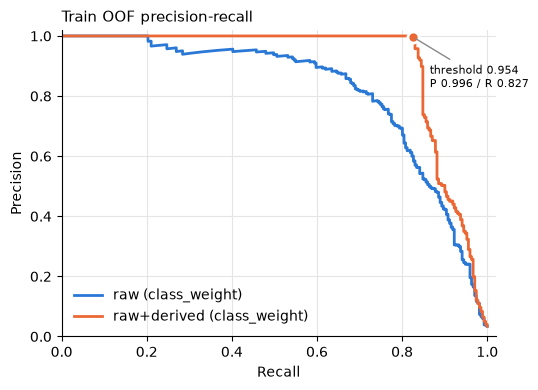

In [7]:
selected = (T.FEATURE_SET, T.IMBALANCE)
chosen = T.best_f1_threshold(y_train, oof[selected])
print(selected, {k: round(v, 4) for k, v in chosen.items()})

fig, ax = plt.subplots(figsize=(5.5, 4))
for (feature_set, color) in [("raw", "#2a78d6"), ("raw+derived", "#eb6834")]:
    p, r, _ = precision_recall_curve(y_train, oof[(feature_set, T.IMBALANCE)])
    ax.plot(r, p, color=color, lw=2, label=f"{feature_set} ({T.IMBALANCE})")
ax.plot(chosen["recall"], chosen["precision"], "o", ms=8, color="#eb6834", mec="white", mew=2)
ax.annotate(f"threshold {chosen['threshold']:.3f}\nP {chosen['precision']:.3f} / R {chosen['recall']:.3f}",
            (chosen["recall"], chosen["precision"]), xytext=(0.865, 0.83), textcoords="data",
            fontsize=8, arrowprops={"arrowstyle": "-", "color": "#888888"})
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.set_title("Train OOF precision-recall", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

**OOF 유형 분류**: 실제 고장(유형 라벨 있음) 중 고장으로 판정한 행에서, 가장 확률이 높은 고장 클래스가 대표 유형과 맞는지 본다.

In [8]:
features = FEATURE_SETS[T.FEATURE_SET]
proba_oof = T.oof_proba(train, features, T.IMBALANCE)
detected = (T.failure_proba(proba_oof) >= chosen["threshold"]) & train["label"].isin(T.CLASSES[1:]).to_numpy()
predicted_type = np.array(CLASSES[1:])[proba_oof[:, 1:].argmax(axis=1)]
pd.crosstab(train.loc[detected, "label"], predicted_type[detected], rownames=["실제"], colnames=["예측"])

예측,HDF,OSF,PWF
실제,,,
HDF,86,0,0
OSF,0,59,1
PWF,0,1,77


## 6. test 평가 (한 번만) — 룰 엔진과 비교

`scripts/train.py`가 만든 모델 파일(`models/model.joblib`)을 불러와 test 2,000행을 판정한다. 노트북에서 다시 학습하지 않고 **실제로 서빙할 파일**을 평가한다.
룰 엔진 수치는 `03_rule_engine.ipynb`와 같은 로직으로 같은 test 행에서 다시 계산한다.

In [9]:
import json
import joblib

model = joblib.load(Path.cwd().parent / "models" / "model.joblib")
meta = json.loads((Path.cwd().parent / "models" / "model_meta.json").read_text())
assert meta["features"] == features and meta["classes"] == CLASSES

proba_test = T.proba_in_class_order(model, to_matrix(test, features))
p_fail_test = T.failure_proba(proba_test)
ml_pred = (p_fail_test >= meta["threshold"]).astype(int)

# 룰 엔진 (03_rule_engine.ipynb, Java RuleEngine과 같은 조건)
osf_limit = test["productType"].map({"L": 11000, "M": 12000, "H": 13000})
hard = (((test["tempDiff"] < 8.6) & (test["rotSpeed"] < 1380))
        | (test["power"] < 3500) | (test["power"] > 9000)
        | (test["wearTorque"] > osf_limit))
warn = test["toolWear"] >= 200


def evaluate(y_pred) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "정밀도": precision_score(y_test, y_pred, zero_division=0),
            "재현율": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0)}


test_result = pd.DataFrame({
    "룰 A. 경고 포함 (≥40)": evaluate((hard | warn).astype(int)),
    "룰 B. 알람만 (≥70)": evaluate(hard.astype(int)),
    f"ML (임계값 {meta['threshold']:.3f})": evaluate(ml_pred),
}).T
print(f"test AP (ML) = {average_precision_score(y_test, p_fail_test):.3f}")
test_result.round(3)

test AP (ML) = 0.906


,TP,FP,FN,TN,정밀도,재현율,F1
룰 A. 경고 포함 (≥40),66.0,149.0,2.0,1783.0,0.307,0.971,0.466
룰 B. 알람만 (≥70),57.0,0.0,11.0,1932.0,1.000,0.838,0.912
ML (임계값 0.954),57.0,0.0,11.0,1932.0,1.000,0.838,0.912


In [10]:
# 유형별 재현율 (test). 유형 라벨 기준이라 여러 유형이 겹친 행은 각 유형에 한 번씩 센다
per_type = []
for failure_type in ["HDF", "PWF", "OSF", "TWF", "RNF"]:
    rows_of_type = (test[failure_type] == 1).to_numpy()
    per_type.append({"유형": failure_type, "라벨 수": int(rows_of_type.sum()),
                     "룰 B 감지": int(hard[rows_of_type].sum()),
                     "ML 감지": int(ml_pred[rows_of_type].sum())})
no_type = ((y_test == 1) & test["label"].isna()).to_numpy()
per_type.append({"유형": "(유형 없음)", "라벨 수": int(no_type.sum()),
                 "룰 B 감지": int(hard[no_type].sum()), "ML 감지": int(ml_pred[no_type].sum())})
pd.DataFrame(per_type).set_index("유형")

,라벨 수,룰 B 감지,ML 감지
유형,,,
HDF,29,29,29
PWF,13,13,13
OSF,16,16,16
TWF,10,1,1
RNF,4,0,0
(유형 없음),2,0,0


In [11]:
# 집계가 같은 것인지, 행 단위로도 같은 판정인지 확인
differs = ml_pred != hard.astype(int).to_numpy()
print(f"ML과 룰 B의 판정이 다른 test 행: {differs.sum()}건 / {len(test)}")
print(f"ML이 TWF를 가장 높은 고장 클래스로 고장 판정한 test 행: "
      f"{int(((proba_test[:, 1:].argmax(axis=1) == CLASSES.index('TWF') - 1) & (ml_pred == 1)).sum())}건")

ML과 룰 B의 판정이 다른 test 행: 0건 / 2000
ML이 TWF를 가장 높은 고장 클래스로 고장 판정한 test 행: 0건


## 7. 정리

**test (2,000행, 고장 68건)**

| 엔진 | 정밀도 | 재현율 | F1 |
|---|---|---|---|
| 룰 A. 경고 포함 (≥40) | 0.307 | 0.971 | 0.466 |
| 룰 B. 알람만 (≥70) | 1.000 | 0.838 | 0.912 |
| ML (원본 + 파생, class_weight) | 1.000 | 0.838 | 0.912 |

**해석**
- **ML은 룰 B와 test의 모든 행에서 같은 판정을 냈다.** 공개된 고장 조건(HDF·PWF·OSF)을 데이터만으로 사실상 그대로 학습했다.
  합성 데이터라 고장 조건이 수식으로 정해져 있기 때문이다 → README의 데이터 한계에 적는다
- **TWF는 두 엔진 모두 거의 못 잡는다 (10건 중 1건, 그 1건도 다른 조건으로 걸린 것).** TWF는 200~240분 구간에서 무작위로 발생해 학습할 패턴이 없다.
  ML은 교차검증에서도 TWF를 고장으로 판정한 적이 없다. 룰 A처럼 "위험 구간 진입" 경고를 주는 방식은 ML의 확률 임계값으로는 만들 수 없다
- RNF와 유형 없는 고장은 예상대로 어떤 엔진도 잡지 못한다
- **"룰이 이렇게 좋은데 ML은 왜 필요한가"에 대한 이 데이터의 답**: 고장 조건을 모르는 상태에서 라벨만으로 룰과 같은 수준에 도달했다.
  조건이 공개된 합성 데이터에서는 이점이 없지만, 실제 현장에서는 조건이 알려져 있지 않은 경우가 많다.
  반대로 TWF처럼 무작위성이 큰 고장은 ML도 못 잡으므로 도메인 지식 기반 경고(룰 A)가 보완한다 → 계층형 판정(확장 아이디어)의 근거
- 응답시간·비용 비교는 MlEngine을 백엔드에 연결한 뒤 Phase 5 벤치마크에서 측정한다

**다음 단계**: `scripts/train.py`가 만든 `models/model.joblib`을 FastAPI `POST /predict`로 서빙한다